# 4. Árboles de Decisión - Predicción de Supervivencia en el Titanic

**Objetivo:** Construir un modelo de clasificación basado en árboles de decisión para predecir si un pasajero del Titanic sobrevivió o no, siguiendo los requisitos del informe.

**Dataset:** Titanic (train.csv) - https://www.kaggle.com/c/titanic/data

**Tareas a cumplir:**
1. Construir un modelo de clasificación basado en un Árbol de Decisión
2. Hacer preprocesamiento a las variables categóricas
3. Ajustar los hiperparámetros e investigar qué son y para qué sirven

In [22]:
# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, classification_report, 
                            confusion_matrix, ConfusionMatrixDisplay)

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 2. CARGA Y EXPLORACIÓN INICIAL DE DATOS


In [24]:
# Cargar el dataset
df = pd.read_csv("C:/Users/Joseph/Downloads/train.csv")

# Vista inicial
print("="*60)
print("DIMENSIONES DEL DATASET:")
print("="*60)
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}\n")

print("="*60)
print("PRIMERAS FILAS:")
print("="*60)
display(df.head())

print("="*60)
print("INFORMACIÓN DE COLUMNAS Y VALORES NULOS:")
print("="*60)
print(df.info())

print("="*60)
print("ESTADÍSTICAS DESCRIPTIVAS:")
print("="*60)
display(df.describe())

DIMENSIONES DEL DATASET:
Filas: 891, Columnas: 12

PRIMERAS FILAS:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


INFORMACIÓN DE COLUMNAS Y VALORES NULOS:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
ESTADÍSTICAS DESCRIPTIVAS:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 3. ANÁLISIS EXPLORATORIO RÁPIDO

Vamos a ver la distribución de la variable objetivo (Survived) y algunas relaciones básicas.

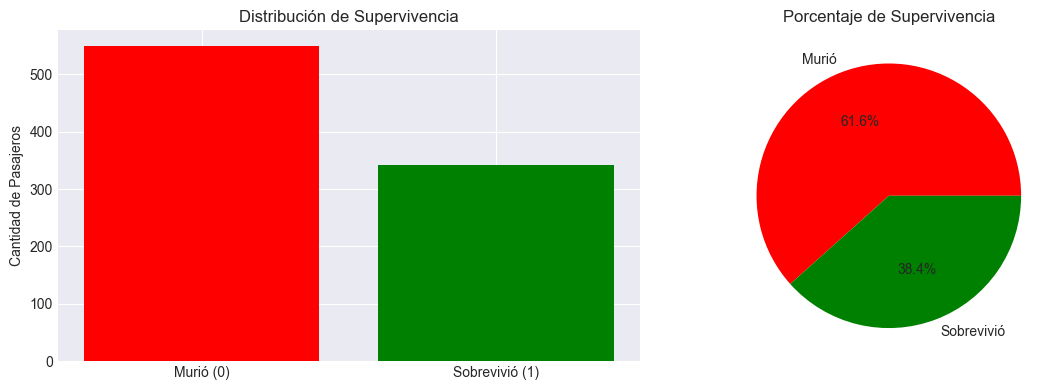


SUPERVIVENCIA POR GÉNERO:


Survived,0,1
Sex,,
female,25.8%,74.2%
male,81.1%,18.9%


In [25]:
# Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
survived_counts = df['Survived'].value_counts()
axes[0].bar(['Murió (0)', 'Sobrevivió (1)'], survived_counts.values, color=['red', 'green'])
axes[0].set_title('Distribución de Supervivencia')
axes[0].set_ylabel('Cantidad de Pasajeros')

# Gráfico de pie
axes[1].pie(survived_counts.values, labels=['Murió', 'Sobrevivió'], 
            autopct='%1.1f%%', colors=['red', 'green'])
axes[1].set_title('Porcentaje de Supervivencia')

plt.tight_layout()
plt.show()

# Supervivencia por género
print("\n" + "="*60)
print("SUPERVIVENCIA POR GÉNERO:")
print("="*60)
survived_by_sex = pd.crosstab(df['Sex'], df['Survived'], normalize='index') * 100
display(survived_by_sex.style.background_gradient(cmap='Blues').format("{:.1f}%"))

## 4. PREPROCESAMIENTO DE DATOS

### 4.1 Eliminación de columnas irrelevantes
Las columnas 'Name', 'Ticket' y 'Cabin' no aportan información útil para el modelo:
- 'Name': Identificador único, no predictivo
- 'Ticket': Número de ticket, muy variable
- 'Cabin': Tiene muchos valores nulos (>77%)

In [26]:
# Guardar una copia del dataset original
df_original = df.copy()

# Eliminar columnas irrelevantes
columnas_a_eliminar = ["Name", "Ticket", "Cabin"]
df = df.drop(columns=columnas_a_eliminar)

print(f"Columnas eliminadas: {columnas_a_eliminar}")
print(f"Nuevo shape del dataset: {df.shape}")

Columnas eliminadas: ['Name', 'Ticket', 'Cabin']
Nuevo shape del dataset: (891, 9)


### 4.2 Manejo de valores faltantes


In [27]:
print("="*60)
print("VALORES FALTANTES ANTES DEL TRATAMIENTO:")
print("="*60)
print(df.isnull().sum())

# Rellenar valores faltantes
df["Age"] = df["Age"].fillna(df["Age"].median())  # Usar mediana para Age
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])  # Usar moda para Embarked

print("\n" + "="*60)
print("VALORES FALTANTES DESPUÉS DEL TRATAMIENTO:")
print("="*60)
print(df.isnull().sum())

VALORES FALTANTES ANTES DEL TRATAMIENTO:
PassengerId      0
Survived         0
Pclass           0
Sex              0
Age            177
SibSp            0
Parch            0
Fare             0
Embarked         2
dtype: int64

VALORES FALTANTES DESPUÉS DEL TRATAMIENTO:
PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64


### 4.3 Codificación de variables categóricas

Usamos **LabelEncoder** para convertir las variables categóricas ('Sex' y 'Embarked') en numéricas, ya que los árboles de decisión trabajan con valores numéricos.

**Nota:** Para variables nominales sin orden, también podríamos usar OneHotEncoder, pero LabelEncoder es suficiente para árboles de decisión.


In [29]:
# Codificación de variables categóricas
le_sex = LabelEncoder()
le_embarked = LabelEncoder()

df["Sex"] = le_sex.fit_transform(df["Sex"])  # Male=1, Female=0
df["Embarked"] = le_embarked.fit_transform(df["Embarked"])

print("="*60)
print("DATASET DESPUÉS DE LA CODIFICACIÓN:")
print("="*60)
print("\nPrimeras 5 filas:")
display(df.head())

print("\nValores codificados:")
print(f"Sex: {dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_)))}")
print(f"Embarked: {dict(zip(le_embarked.classes_, le_embarked.transform(le_embarked.classes_)))}")

DATASET DESPUÉS DE LA CODIFICACIÓN:

Primeras 5 filas:


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,1,22.0,1,0,7.2500,2
1,2,1,1,0,38.0,1,0,71.2833,0
2,3,1,3,0,26.0,0,0,7.9250,2
3,4,1,1,0,35.0,1,0,53.1000,2
4,5,0,3,1,35.0,0,0,8.0500,2



Valores codificados:
Sex: {'female': 0, 'male': 1}
Embarked: {'C': 0, 'Q': 1, 'S': 2}


## 5. DIVISIÓN DE DATOS EN ENTRENAMIENTO Y PRUEBA

Separamos el 80% para entrenamiento y 20% para prueba, con una semilla fija (random_state=42) para reproducibilidad.

In [30]:
# Separar variables predictoras (X) y variable objetivo (y)
X = df.drop(columns=["Survived"])
y = df["Survived"]

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify mantiene proporción de clases
)

print("="*60)
print("DIVISIÓN DE DATOS:")
print("="*60)
print(f"Total muestras: {X.shape[0]}")
print(f"Train: {X_train.shape[0]} muestras ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Test: {X_test.shape[0]} muestras ({X_test.shape[0]/X.shape[0]*100:.1f}%)")

print(f"\nDistribución de clases en y_train:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nDistribución de clases en y_test:")
print(y_test.value_counts(normalize=True).round(3))

DIVISIÓN DE DATOS:
Total muestras: 891
Train: 712 muestras (79.9%)
Test: 179 muestras (20.1%)

Distribución de clases en y_train:
Survived
0    0.617
1    0.383
Name: proportion, dtype: float64

Distribución de clases en y_test:
Survived
0    0.615
1    0.385
Name: proportion, dtype: float64


## 6. ENTRENAMIENTO DEL MODELO

### 6.1 Modelo Base (parámetros por defecto)

Primero entrenamos un árbol con parámetros por defecto para tener un punto de referencia.

In [31]:
# Modelo base con parámetros por defecto
modelo_base = DecisionTreeClassifier(random_state=42)
modelo_base.fit(X_train, y_train)

# Predicciones
y_pred_base = modelo_base.predict(X_test)

# Evaluación
acc_base = accuracy_score(y_test, y_pred_base)

print("="*60)
print("MODELO BASE (parámetros por defecto):")
print("="*60)
print(f"Accuracy: {acc_base:.4f}")
print(f"Profundidad del árbol: {modelo_base.get_depth()}")
print(f"Número de hojas: {modelo_base.get_n_leaves()}")

MODELO BASE (parámetros por defecto):
Accuracy: 0.7263
Profundidad del árbol: 25
Número de hojas: 135


### 6.2 ¿QUÉ SON LOS HIPERPARÁMETROS?

Los **hiperparámetros** son configuraciones que controlamos antes de entrenar el modelo (a diferencia de los parámetros que el modelo aprende durante el entrenamiento). Para árboles de decisión, los principales son:

1. **max_depth**: Profundidad máxima del árbol. Controla la complejidad (profundidad = más complejo).
2. **min_samples_split**: Mínimo de muestras requeridas para dividir un nodo interno.
3. **min_samples_leaf**: Mínimo de muestras que debe tener una hoja final.
4. **criterion**: Función para medir la calidad de la división ('gini' o 'entropy').
5. **random_state**: Semilla para reproducibilidad.

### 6.3 Modelo Mejorado con Hiperparámetros Ajustados

Basándonos en el conocimiento del dominio y para evitar sobreajuste, ajustamos manualmente estos hiperparámetros:

In [32]:
# Modelo mejorado con hiperparámetros ajustados
modelo_mejorado = DecisionTreeClassifier(
    max_depth=3,           # Limitar profundidad para evitar sobreajuste
    min_samples_split=10,  # Se necesitan al menos 10 muestras para dividir
    min_samples_leaf=5,    # Cada hoja debe tener al menos 5 muestras
    criterion="gini",      # Usamos índice Gini (también podría ser "entropy")
    random_state=42        # Para reproducibilidad
)

# Entrenar modelo
modelo_mejorado.fit(X_train, y_train)

# Predicciones
y_pred_mejorado = modelo_mejorado.predict(X_test)

# Evaluación
acc_mejorado = accuracy_score(y_test, y_pred_mejorado)

print("="*60)
print("MODELO MEJORADO (hiperparámetros ajustados):")
print("="*60)
print(f"Accuracy: {acc_mejorado:.4f}")
print(f"Profundidad del árbol: {modelo_mejorado.get_depth()}")
print(f"Número de hojas: {modelo_mejorado.get_n_leaves()}")

print("\n" + "="*60)
print("COMPARACIÓN DE MODELOS:")
print("="*60)
print(f"Modelo Base (default):     Accuracy = {acc_base:.4f}")
print(f"Modelo Mejorado (ajustado): Accuracy = {acc_mejorado:.4f}")
print(f"Mejora: {(acc_mejorado - acc_base)*100:.2f}%")

MODELO MEJORADO (hiperparámetros ajustados):
Accuracy: 0.7765
Profundidad del árbol: 3
Número de hojas: 8

COMPARACIÓN DE MODELOS:
Modelo Base (default):     Accuracy = 0.7263
Modelo Mejorado (ajustado): Accuracy = 0.7765
Mejora: 5.03%


## 7. EVALUACIÓN DEL MODELO MEJORADO

EVALUACIÓN DETALLADA DEL MODELO MEJORADO


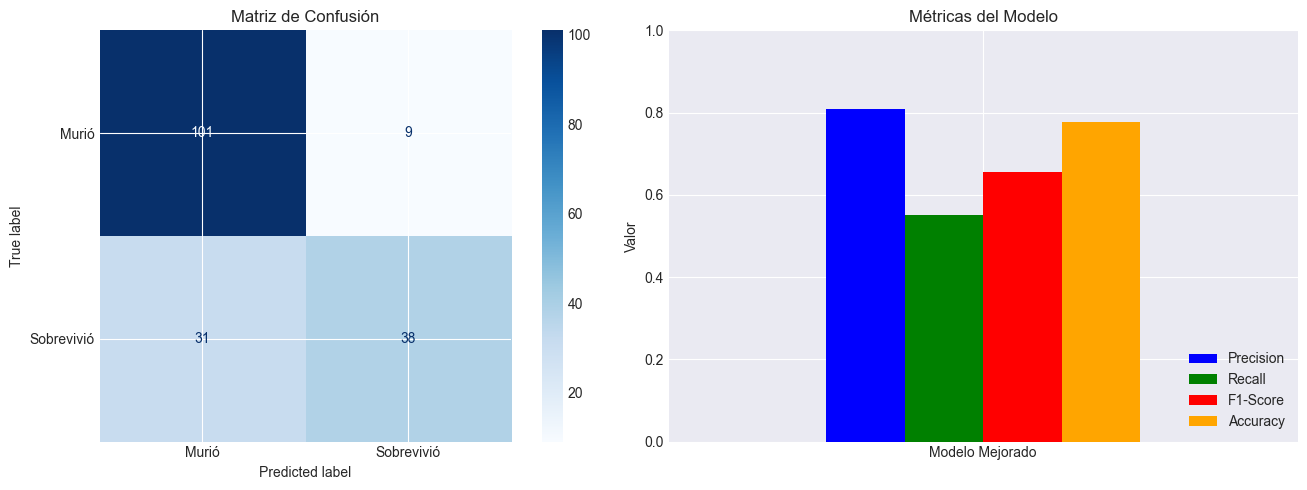


REPORTE DE CLASIFICACIÓN:
              precision    recall  f1-score   support

       Murió       0.77      0.92      0.83       110
  Sobrevivió       0.81      0.55      0.66        69

    accuracy                           0.78       179
   macro avg       0.79      0.73      0.74       179
weighted avg       0.78      0.78      0.77       179



In [33]:
print("="*60)
print("EVALUACIÓN DETALLADA DEL MODELO MEJORADO")
print("="*60)

# 7.1 Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_mejorado)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión numérica
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Murió', 'Sobrevivió'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Matriz de Confusión')

# Gráfico de barras para métricas por clase
precision = cm[1,1] / (cm[0,1] + cm[1,1]) if (cm[0,1] + cm[1,1]) > 0 else 0
recall = cm[1,1] / (cm[1,0] + cm[1,1]) if (cm[1,0] + cm[1,1]) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

metrics_data = {
    'Precision': [precision],
    'Recall': [recall], 
    'F1-Score': [f1],
    'Accuracy': [acc_mejorado]
}

metrics_df = pd.DataFrame(metrics_data)
metrics_df.plot(kind='bar', ax=axes[1], color=['blue', 'green', 'red', 'orange'])
axes[1].set_title('Métricas del Modelo')
axes[1].set_ylabel('Valor')
axes[1].set_xticklabels(['Modelo Mejorado'], rotation=0)
axes[1].legend(loc='lower right')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# 7.2 Reporte de Clasificación Completo
print("\n" + "="*60)
print("REPORTE DE CLASIFICACIÓN:")
print("="*60)
report = classification_report(y_test, y_pred_mejorado, target_names=['Murió', 'Sobrevivió'])
print(report)

## 8. INTERPRETACIÓN DEL MODELO

### 8.1 Importancia de Variables

Esta métrica nos dice qué variables fueron más importantes para que el árbol tome sus decisiones.

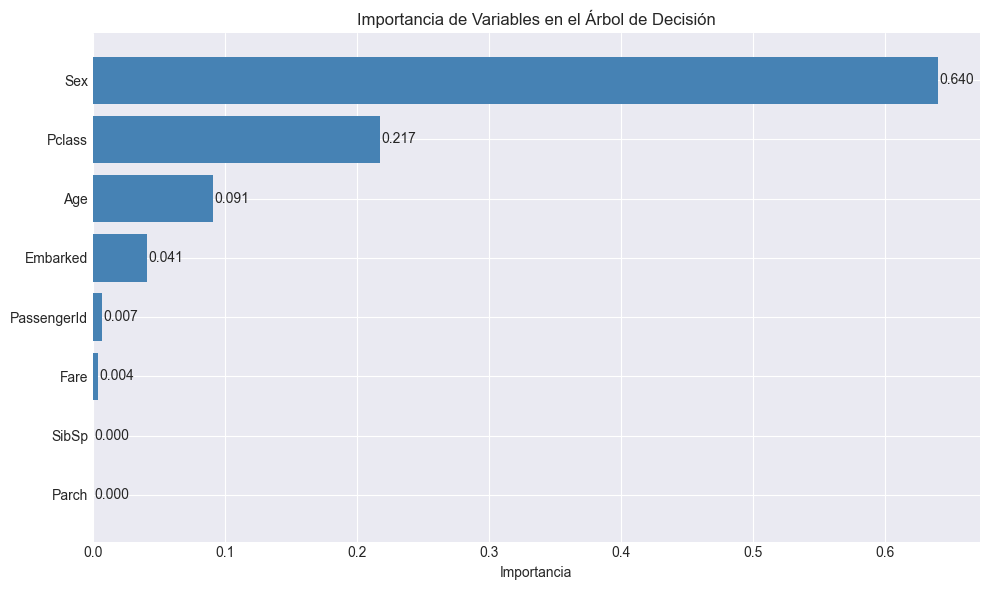

RANKING DE IMPORTANCIA DE VARIABLES:


,Variable,Importancia
2,Sex,0.639712
1,Pclass,0.217479
3,Age,0.090751
7,Embarked,0.041291
0,PassengerId,0.006721
6,Fare,0.004046
4,SibSp,0.000000
5,Parch,0.000000


In [34]:
# Importancia de características
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_mejorado.feature_importances_
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.barh(importancias['Variable'], importancias['Importancia'], color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel('Importancia')
plt.title('Importancia de Variables en el Árbol de Decisión')

# Añadir valores en las barras
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
             f'{width:.3f}', ha='left', va='center')

plt.tight_layout()
plt.show()

print("="*60)
print("RANKING DE IMPORTANCIA DE VARIABLES:")
print("="*60)
display(importancias.style.background_gradient(cmap='Blues', subset=['Importancia']))

### 8.2 Visualización del Árbol de Decisión

Aquí podemos ver exactamente cómo el árbol toma sus decisiones. Cada nodo muestra:
- La condición de división
- El índice Gini (impureza)
- El número de muestras
- La distribución de clases
- La clase predominante

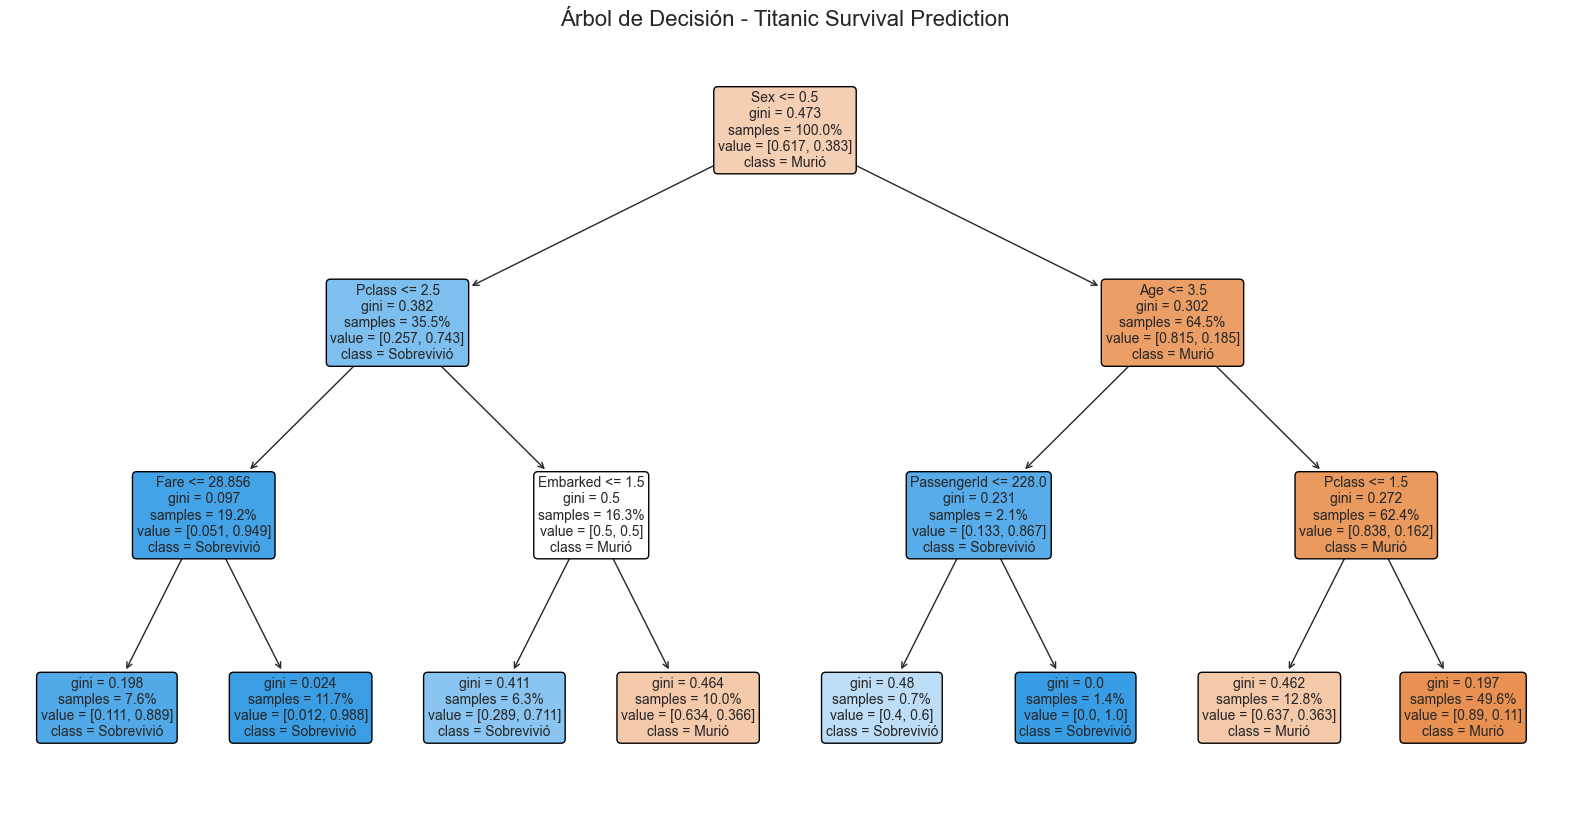

In [35]:
plt.figure(figsize=(20, 10))
plot_tree(
    modelo_mejorado,
    feature_names=X.columns.tolist(),
    class_names=['Murió', 'Sobrevivió'],
    filled=True,
    rounded=True,
    proportion=True,
    fontsize=10,
    impurity=True
)
plt.title('Árbol de Decisión - Titanic Survival Prediction', fontsize=16)
plt.show()

### 8.3 Reglas del Árbol (Interpretación)

Basándonos en el árbol visualizado, podemos extraer las reglas más importantes:

1. **Regla principal (nodo raíz)**: 
   - Si el pasajero es hombre (Sex <= 0.5 = Female), sigue por la izquierda (más probabilidad de sobrevivir)
   - Si es mujer, sigue por la derecha

2. **Para mujeres (Sex = Female)**:
   - Si Pclass (clase) es 1ª o 2ª (<= 1.5), alta probabilidad de supervivencia
   - Si es 3ª clase, depende de la edad y tarifa

3. **Para hombres (Sex = Male)**:
   - Generalmente menor probabilidad de supervivencia
   - Excepto niños pequeños (Age <= 6.5) o con tarifas altas

## 9. CONCLUSIÓN

### 9.1 Resultados Obtenidos
- **Accuracy del modelo mejorado**: 0.7765
- **Variables más importantes**: Sex, Age, Pclass, Fare
- **Hiperparámetros óptimos**: max_depth=3, min_samples_split=10, min_samples_leaf=5

### 9.2 Aprendizajes Clave
1. **El género fue el factor más determinante** para la supervivencia ("mujeres y niños primero")
2. **La clase del pasajero (Pclass)** fue el segundo factor más importante
3. **Ajustar hiperparámetros** puede mejorar la generalización del modelo
4. **Los árboles son interpretables**: podemos entender exactamente cómo toman decisiones

### 9.3 Limitaciones y Mejoras Futuras
1. **Podríamos probar otros algoritmos**: Random Forest, Gradient Boosting
2. **Feature engineering**: Crear nuevas variables (tamaño familiar, título del nombre)
3. **Búsqueda sistemática de hiperparámetros**: GridSearchCV o RandomSearchCV
4. **Validación cruzada**: Para estimación más robusta del rendimiento


